In [2]:
# Danila Valko
# April 2026

### Setup

In [7]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from numbers import Number
from scipy import stats
from itertools import pairwise
from scipy.stats import mannwhitneyu, friedmanchisquare, wilcoxon
import warnings

warnings.filterwarnings("ignore")

In [8]:
base_dir = './'
data_dir = os.path.join(base_dir, 'data')
figures_dir = os.path.join(base_dir, 'figures')
os.makedirs(figures_dir, exist_ok=True)  

cleaned_data = pd.read_csv(os.path.join(data_dir, 'cleaned_data.csv'))

In [9]:
def q(s, data):
    ret = []
    if isinstance(s, list):
        for i in s:
            j = q(i, data)
            if pd.notna(j):
                ret += [j]
        return ret
    for i in data.columns:
        if i.startswith(s):
            return i
    return s
        
def draw_pie(data, nrows=1, ncols=1, titles=None, labeldistance=1.2, file_name=None, width=4, height=4.5):
    plt.close()
    fig = plt.figure(figsize=(width*ncols, height*nrows))
    for i, c in enumerate(data.columns):
        ax = fig.add_subplot(nrows, ncols, i+1)
        d = data[c].value_counts() / len(data) * 100
        d.sort_index(inplace=True)
        d.index = [f"{v:.1f}%\n{i}" for i, v in d.items()]
        wedges, texts = ax.pie(
            d.values,
            labels=d.index,
            #startangle=90,
            labeldistance=labeldistance,
            textprops={'fontsize': 11.5},
            colors=sns.color_palette('Set2'),
        )
        if titles:
            ax.set_title(f"{titles[i]}\n",#\n($n=${len(data)})", 
                         fontdict={'fontsize': 12,
                                   'verticalalignment': 'bottom',
                                   'horizontalalignment': 'center'})
    fig.tight_layout(pad=0.5, h_pad=0, w_pad=0.1)
    if file_name is not None:
        fig.savefig(os.path.join(figures_dir, f'{file_name}.pdf'), dpi=1200, bbox_inches='tight', format='pdf')
    return ax
        

def radar_chart_ci(
    questions,
    columns,
    data,
    labels={},
    title=None,
    file_name=None,
    left=3,
    ci=0.95,
    ci_method="sem",  # "sem", "std", or "quantile"
    loc="upper center",
    linestyle='--',
    verbose=True,
    figsize=(5.5, 5.5),
    add_stars=False
):
    plt.close()
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(polar=True)
    categories = [labels.get(q, q) for q in questions[:-1]]
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1], categories, size=11)
    ax.set_rlabel_position(0)
    ax.set_yticks([1, 2, 3, 4, 5], ["1", "2", "3", "4", "5"], color="grey", size=11)
    ax.set_ylim(0, 5)
    df = data[columns].dropna()
    group_col = columns[-1]
    value_cols = columns[:-1][:N]
    z = stats.norm.ppf(1 - (1 - ci) / 2)
    differences = {}
    for idx, group in enumerate(df[group_col].drop_duplicates().sort_values()):
        differences.setdefault(group_col, {})
        d = df[df[group_col] == group][value_cols]
        differences[group_col][group] = d
        m = d.mean()
        if verbose:
            print(f"Group: {group_col}:{group} = {m}")
        std = d.std()
        n = d.count()
        if ci_method == "std":
            lower = m - std
            upper = m + std
        elif ci_method == "quantile":
            lower = d.quantile((1 - ci) / 2)
            upper = d.quantile(1 - (1 - ci) / 2)
        else:  # SEM (default)
            sem = std / np.sqrt(n)
            lower = m - z * sem
            upper = m + z * sem
        # close polygons
        mean_vals = m.tolist() + [m.iloc[0]]
        lower_vals = lower.tolist() + [lower.iloc[0]]
        upper_vals = upper.tolist() + [upper.iloc[0]]
        if isinstance(linestyle, str):
            ls = linestyle
        else:
            if group in linestyle:
                ls = linestyle[group]
            else:                
                ls = '--'
        line, = ax.plot(angles, mean_vals, 'o-', linewidth=2, label=group, linestyle=ls,
                        color=sns.color_palette('Set2')[idx])
        ax.fill_between(
            angles,
            lower_vals,
            upper_vals,
            alpha=0.2,
            color=line.get_color()
        )
    for k, v in differences.items():
        for (i0, d0), (i1, d1) in list(pairwise(v.items())):
            for col in d0.columns:
                if verbose:
                    print(f"\nComparing groups by {col}:")
                    print(f"avg. {i0}: {d0[col].mean():.2f}")
                    print(f"avg. {i1}: {d1[col].mean():.2f}")
                    u, p = mannwhitneyu(d0[col], d1[col])
                    print(f"Mann-Whitney U test: U={u:.1f}, p={p:.4f}")
    if loc is not None:
        leg = ax.legend(
            loc=loc,
            bbox_to_anchor=(0.5, -0.10),
            ncol=N,
            fontsize=11,
            frameon=False
        )
        if questions[-1] in labels:
            lb = labels[questions[-1]]
            p = leg.get_window_extent()
            ax.annotate(
                lb,
                (np.min([p.p0[0] - left * len(lb) / 2, p.p1[0]]),
                np.max([p.p0[1], p.p1[1]])),
                xycoords="figure pixels",
                zorder=9,
                size=12
            )
    if title:
        ax.set_title(
            f"{title}\n",
            fontdict={
                "fontsize": 11,
                "verticalalignment": "top",
                "horizontalalignment": "center",
            },
        )
    fig.tight_layout()
    if file_name:
        fig.savefig(os.path.join(figures_dir, f"{file_name}.pdf"),
                    dpi=1200, bbox_inches="tight")
    return ax

def radar_chart(questions, columns, data, 
    labels={}, 
    title=None, 
    file_name=None, 
    left=3,
    loc="upper center",
    linestyle='--',
    verbose=True,
    no_fill=True, figsize=(5.5, 5.5)):
    plt.close()
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(polar=True)  
    categories = [i if i not in labels else labels[i] for i in questions[:-1]]
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1], categories, size=12)
    ax.tick_params(axis='x', pad=30)
    ax.set_rlabel_position(0)
    ax.set_yticks([1,2,3,4,5], ["1","2","3","4","5"], color="grey", size=11)
    ax.set_ylim(0,5)
    df = data[columns].dropna()
    for idx, i in enumerate(df[columns[-1]].drop_duplicates().sort_values()):
        d = df[df[columns[-1]] == i].dropna()
        d = d[d.columns[:len(categories)]].mean()
        if verbose:
            print(i)
            print(d)
        d = list(d.values) + [d.values[0]]
        if isinstance(linestyle, str):
            ls = linestyle
        else:
            if i in linestyle:
                ls = linestyle[i]
            else:                
                ls = '--'
        ax.plot(angles, d, 'o-', linewidth=2, label=i, linestyle=ls,
                color=sns.color_palette('Set2')[idx])
        if not no_fill:
            ax.fill(angles, d, alpha=0.2)
    if loc is not None:
        leg = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10),
            fancybox=False, shadow=False, ncol=N if N <=4 else round(N/2), fontsize=11, frameon=False)
        p = leg.get_window_extent()
        if questions[-1] in labels:
            lb = labels[questions[-1]] 
            ax.annotate(lb, (np.min([p.p0[0] - left * len(lb) / 2, p.p1[0]]), 
                            np.max([p.p0[1], p.p1[1]])), xycoords='figure pixels', zorder=9, size=12)
        #ax.text(0.55, 6, f"$n=${len(df)}", fontsize=11)
    if title:
        ax.set_title(f"{title}\n",#($n=${len(data)})\n", 
                         fontdict={'fontsize': 11,
                                   'verticalalignment': 'top',
                                   'horizontalalignment': 'center'})
    fig.tight_layout()
    if file_name is not None:
        fig.savefig(os.path.join(figures_dir, f'{file_name}.pdf'), dpi=1200, bbox_inches='tight', format='pdf')
    return ax

def draw_hbar(questions, columns, data, file_name=None,
       labels={}, xlabel=None, ylabel=None, figsize=(9, 4.5), annot=None):
    df = data.copy()
    plt.close()
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot()
    sns.barplot(df, ax=ax, palette="Set2", orient='h', ci=95)
    ax.set_xlim(0.9, 5.3)
    ax.set_xticks([1,2,3,4,5], ["1","2","3","4","5"], size=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    q = [labels[i] if i in labels else i for i in questions]
    ax.set_yticklabels(q, size=12)
    if annot:
        for i, (bar, value) in enumerate(zip(ax.patches, annot)):
            ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2 - 0.2, value, ha='left', va='center', fontsize=11)
    fig.tight_layout()
    if file_name is not None:
        fig.savefig(os.path.join(figures_dir, f'{file_name}.pdf'), dpi=1200, bbox_inches='tight', format='pdf')
    return ax

def get_stars(p, p001="***", p01="**", p05="*", p10="⁺", p_=""):
    if not isinstance(p, Number):
        return p
    if p < 0.001:
        return p001
    if p < 0.010:
        return p01
    if p < 0.050:
        return p05
    if p < 0.100:
        return p10
    return p_

### Figures

27


['How many years of experience do you have in research or development?']

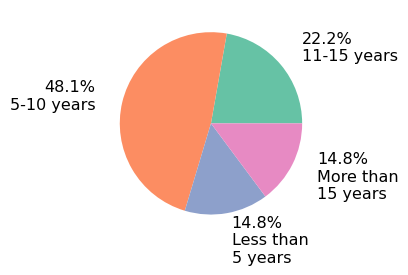

In [10]:
qs = ['How many years of experience do you have in research or development?',   ]
df = cleaned_data.copy()
df = df[df['Selected_expert'] == 1]
qq = q(qs, df)
df = df[qq].dropna().replace({
    '5–10': '5-10 years',
    '11–15': '11-15 years',
    'Less than 5': 'Less than\n5 years',
    'More than 15': 'More than\n15 years',
    np.nan: 'No data',
    None: 'No data',
})
print(len(df))
draw_pie(df, nrows=1, ncols=1, file_name='fig01a', 
         labeldistance=1.3, 
         width=4, height=4.5)
qq

27


['What is your level of education or expertise?']

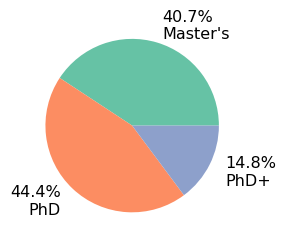

In [11]:
qs = ['What is your level of education or expertise?',   ]
df = cleaned_data.copy()
df = df[df['Selected_expert'] == 1]
qq = q(qs, df)
df = df[qq].dropna().replace({
    'PhD+ (Prof., Group Lead etc.)': 'PhD+',
    np.nan: 'No data',
    None: 'No data',
})
print(len(df))
draw_pie(df, nrows=1, ncols=1, file_name='fig01b', 
         labeldistance=1.2, width=2.8, height=4.5)
qq

27


['Do you have experience collecting data or preparing datasets for research purposes?']

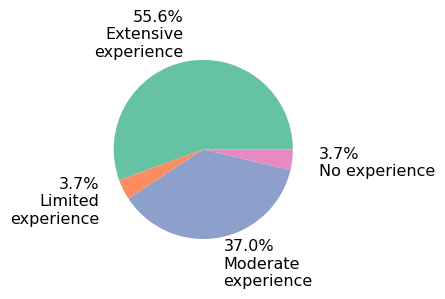

In [12]:
qs = ['Do you have experience collecting data or preparing datasets for research purposes?',   ]
df = cleaned_data.copy()
df = df[df['Selected_expert'] == 1]
qq = q(qs, df)
df = df[qq].dropna().replace({
    'No experience': 'No experience',
    'Limited experience (did it once)': 'Limited\nexperience',
    'Moderate experience (did it more than once)': 'Moderate\nexperience',
    'Moderate experience': 'Moderate\nexperience',
    'Extensive experience': 'Extensive\nexperience',
    np.nan: 'No data',
    None: 'No data',
})
print(len(df))
draw_pie(df, nrows=1, ncols=1, file_name='fig01c',
         labeldistance=1.3,
            width=4.2, height=4)                          
qq

27


['Do you have experience developing software or using programming languages for research?']

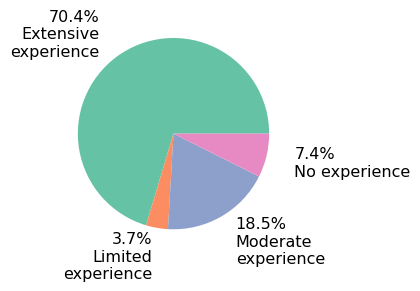

In [13]:
qs = ['Do you have experience developing software or using programming languages for research?',   ]
df = cleaned_data.copy()
df = df[df['Selected_expert'] == 1]
qq = q(qs, df)
df = df[qq].dropna().replace({
    'No experience': 'No experience',
    'Limited experience (did it once)': 'Limited\nexperience',
    'Moderate experience (did it more than once)': 'Moderate\nexperience',
    'Moderate experience': 'Moderate\nexperience',
    'Extensive experience': 'Extensive\nexperience',
    np.nan: 'No data',
    None: 'No data',
})
print(len(df))
draw_pie(df, nrows=1, ncols=1, file_name='fig01d',
         labeldistance=1.3,
            width=4., height=4)                          
qq

27


<Axes: >

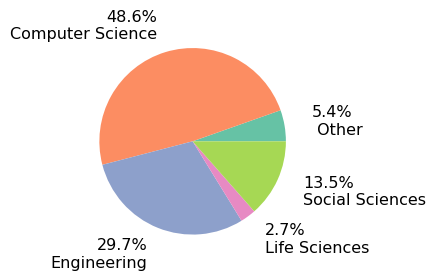

In [14]:
qs = ['What is your primary field of research or development? [Computer Science related]', 
      'What is your primary field of research or development? [Engineering related]', 
      'What is your primary field of research or development? [Social Sciences related]', 
      'What is your primary field of research or development? [Life Sciences related]', 
      'What is your primary field of research or development? [Other]']
df = cleaned_data.copy()
df = df[df['Selected_expert'] == 1]
qq = q(qs, df)

df = df[qq].replace({
    'Yes': 1,
    'No': np.nan,
})
print(len(df))
df[qq[0]] = df[qq[0]].map({
    1: 'Computer Science',
    0: np.nan,
})
df[qq[1]] = df[qq[1]].map({
    1: 'Engineering',
    0: np.nan,
})
df[qq[2]] = df[qq[2]].map({
    1: 'Social Sciences',
    0: np.nan,
})
df[qq[3]] = df[qq[3]].map({
    1: 'Life Sciences',
    0: np.nan,
})
df[qq[4]] = df[qq[4]].apply(lambda x: 'Other' if not pd.isna(x) else np.nan)

df = pd.DataFrame(pd.concat([df[i] for i in df.columns], axis=0).dropna()).replace({
    'Other': ' Other',
    np.nan: 'No data',
    None: 'No data',
})

draw_pie(df, nrows=1, ncols=1, file_name='fig02', width=4, height=4,
         labeldistance=1.3, )


27
Group: Category:Average value = How familiar are you with the FAIR principles (Findable, Accessible, Interoperable, Reusable, see the introductory paper)? 1 (Not familiar) – 5 (Very familiar)    3.962963
How familiar are you with the sustainability concept (e.g., Sustainable Development Goals) in general? 1 (Not familiar) – 5 (Very familiar)                        3.592593
How familiar are you with green software practices in general? 1 (Not familiar) – 5 (Very familiar)                                                                2.666667
dtype: float64


<PolarAxes: >

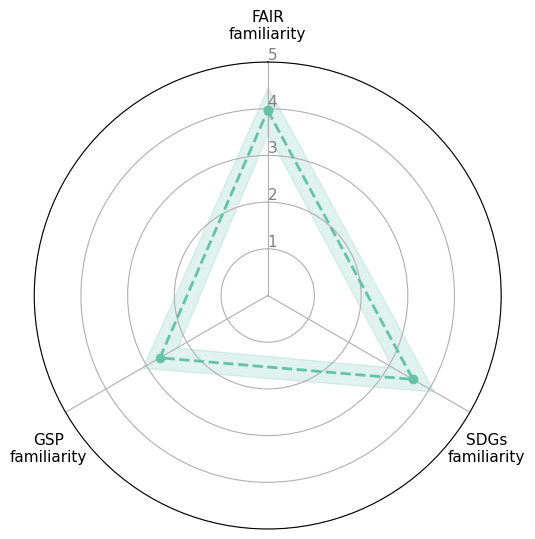

In [15]:
qs = ['How familiar are you with the FAIR principles (Findable, Accessible, Interoperable, Reusable, see the introductory paper)? 1 (Not familiar) – 5 (Very familiar)', 
      'How familiar are you with the sustainability concept (e.g., Sustainable Development Goals) in general? 1 (Not familiar) – 5 (Very familiar)',
      'How familiar are you with green software practices in general? 1 (Not familiar) – 5 (Very familiar)', ]
df = cleaned_data.copy()
df = df[df['Selected_expert'] == 1]
qq = q(qs, df)
df = df[qq].dropna()
print(len(df))
df['Category'] = 'Average value'
radar_chart_ci(qs+['Category'], qq+['Category'], df, labels={
    qs[0]: 'FAIR\nfamiliarity\n\n',
    qs[1]: '\n\n\nSDGs\nfamiliarity',
    qs[2]: '\n\n\nGSP\nfamiliarity',
}, 
file_name='fig03', left=1, ci=0.95, ci_method="sem", 
loc=None,
linestyle='--')

27


['How often do you participate in editorial boards, research or conference committees, or grant review activities that assess paper submissions or funding applications?']

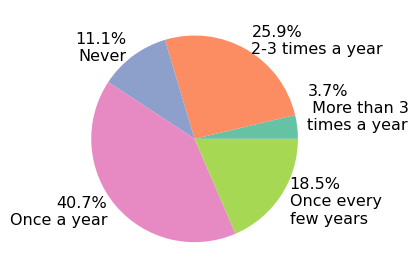

In [16]:
qs = ['How often do you participate in editorial boards, research or conference committees, or grant review activities that assess paper submissions or funding applications?',   ]
df = cleaned_data.copy()
df = df[df['Selected_expert'] == 1]
qq = q(qs, df)
df = df[qq].dropna().replace({
    'Once every few years': 'Once every\nfew years',
    '2–3 times a year': '2-3 times a year',
    'More than 3 times a year': ' More than 3\ntimes a year\n\n',
    np.nan: 'No data',
    None: 'No data',
})
print(len(df))
draw_pie(df, nrows=1, ncols=1, file_name='fig04', width=4, height=4,
         labeldistance=1.1, )

qq

How familiar are you with the FAIR principles (Findable, Accessible, Interoperable, Reusable, see the introductory paper)? 1 (Not familiar) – 5 (Very familiar)    3.962963
How important is it to follow FAIR principles? 1 (Not important) – 5 (Extremely important)                                                                         4.400000
To what extent do you apply the FAIR principles in your research or software development work? 1 (Never apply) – 5 (Always apply)                                  3.814815
dtype: float64
27 13
Group: Category:Other participants = How familiar are you with the FAIR principles (Findable, Accessible, Interoperable, Reusable, see the introductory paper)? 1 (Not familiar) – 5 (Very familiar)    3.8
How important is it to follow FAIR principles? 1 (Not important) – 5 (Extremely important)                                                                         3.7
To what extent do you apply the FAIR principles in your research or software development wor

'*'

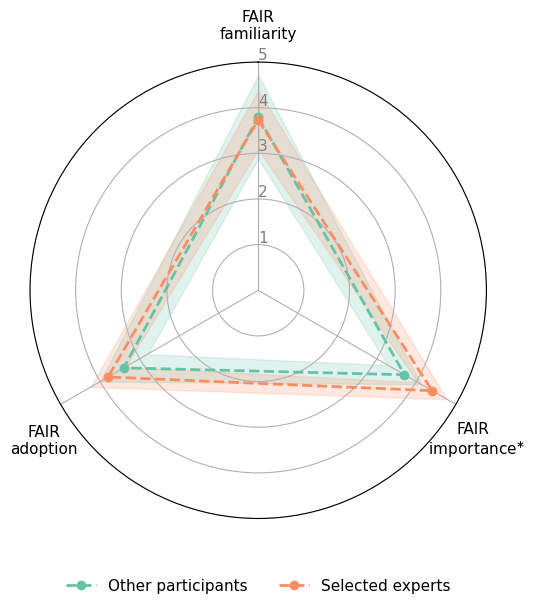

In [17]:
qs = ['How familiar are you with the FAIR principles (Findable, Accessible, Interoperable, Reusable, see the introductory paper)? 1 (Not familiar) – 5 (Very familiar)',
      'How important is it to follow FAIR principles? 1 (Not important) – 5 (Extremely important)',              
      'To what extent do you apply the FAIR principles in your research or software development work? 1 (Never apply) – 5 (Always apply)',
]
df = cleaned_data.copy()
qq = q(qs, df)
df1 = df[df['Selected_expert'] == 1]
df1 = df1[qq]
df1['Category'] = 'Selected experts'
print(df1.mean(numeric_only=True))
df2 = df[df['Selected_expert'] == 0]
df2 = df2[qq]
df2 = df2[~df2.index.isin(df1.index)]
df2['Category'] = 'Other participants'
print(len(df1), len(df2))
df = pd.concat([df1, df2], ignore_index=True)
radar_chart_ci(qs+['Category'], qq+['Category'], df, labels={
    qs[0]: 'FAIR\nfamiliarity\n\n',
    qs[1]: '\n\n\nFAIR\n  importance$^{\\ast}$',
    qs[2]: '\n\n\nFAIR\nadoption',
},
file_name='fig05a', left=1, ci=0.95, ci_method="sem", 
loc="upper center", 
linestyle='--', figsize=(5.5, 6.5))
get_stars(0.0221)

In [18]:
d = df.groupby('Category').mean(numeric_only=True).map(lambda x: f"{x:.2f}").T
d.to_csv(os.path.join(figures_dir, "fig05b.csv"), index=True)
d

Category,Other participants,Selected experts
"How familiar are you with the FAIR principles (Findable, Accessible, Interoperable, Reusable, see the introductory paper)? 1 (Not familiar) – 5 (Very familiar)",3.77,3.96
How important is it to follow FAIR principles? 1 (Not important) – 5 (Extremely important),3.82,4.40
To what extent do you apply the FAIR principles in your research or software development work? 1 (Never apply) – 5 (Always apply),3.42,3.81


20
Friedman chi-square: 8.496644295301992
p-value: 0.07498900973491922
Which FAIR+S principles (S1–S5) do you find most critical for adoption? 1 (Not important) – 5 (Very important) [S1 Energy efficiency attributes]: p=0.009
Which FAIR+S principles (S1–S5) do you find most critical for adoption? 1 (Not important) – 5 (Very important) [S2 Sustainability benchmarks]: p=0.021
Which FAIR+S principles (S1–S5) do you find most critical for adoption? 1 (Not important) – 5 (Very important) [S3 Alignment with sustainability frameworks]: p=0.028
Which FAIR+S principles (S1–S5) do you find most critical for adoption? 1 (Not important) – 5 (Very important) [S4 Carbon transparency and accountability]: p=0.014
Which FAIR+S principles (S1–S5) do you find most critical for adoption? 1 (Not important) – 5 (Very important) [S5 Life cycle sustainability]: p=0.151


<Axes: >

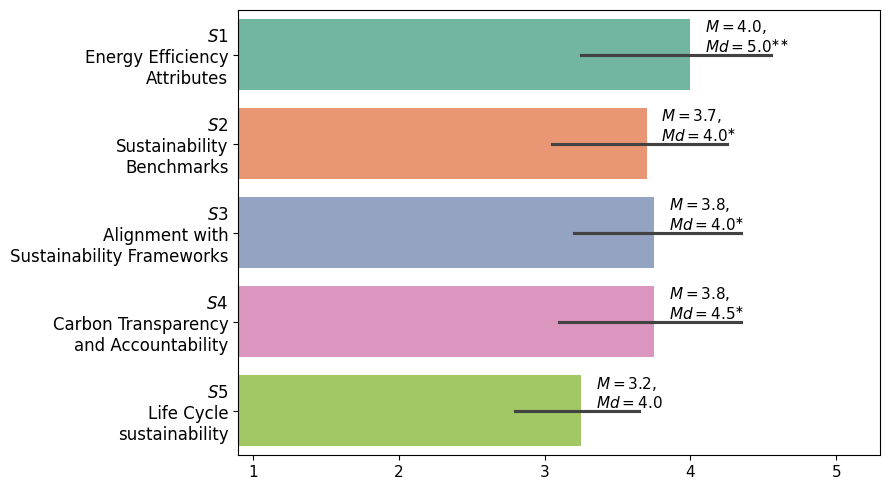

In [19]:
qs = ['Which FAIR+S principles (S1–S5) do you find most critical for adoption? 1 (Not important) – 5 (Very important) [S1 Energy efficiency attributes]',
      'Which FAIR+S principles (S1–S5) do you find most critical for adoption? 1 (Not important) – 5 (Very important) [S2 Sustainability benchmarks]',
      'Which FAIR+S principles (S1–S5) do you find most critical for adoption? 1 (Not important) – 5 (Very important) [S3 Alignment with sustainability frameworks]',
      'Which FAIR+S principles (S1–S5) do you find most critical for adoption? 1 (Not important) – 5 (Very important) [S4 Carbon transparency and accountability]',
      'Which FAIR+S principles (S1–S5) do you find most critical for adoption? 1 (Not important) – 5 (Very important) [S5 Life cycle sustainability]']
df = cleaned_data.copy()
qq = q(qs, df)
df = df[df['Selected_expert'] == 1]
df = df[qq].astype(float).dropna()
print(len(df))
stat, p = friedmanchisquare(*[df[col].values for col in df.columns])
print("Friedman chi-square:", stat) # Friedman → “Are categories different?”
print("p-value:", p) # p < 0.05 → at least one category differs in importance

pvals = []
for col in df.columns:
    _, p = wilcoxon(df[col] - 3, alternative='greater') # p < 0.05 → ratings are significantly different from 3
    print(f"{col}: p={p:.3f}")
    pvals.append(f"$M={np.mean(df[col]):.1f}$,\n$Md={np.median(df[col]):.1f}^{{{get_stars(p)}}}$".replace('*', r'{\ast}'))

draw_hbar(qs, qq, df, labels={
    qs[0]: '$S1$\nEnergy Efficiency\nAttributes',
    qs[1]: '$S2$\nSustainability\nBenchmarks',
    qs[2]: '$S3$\nAlignment with\nSustainability Frameworks',
    qs[3]: '$S4$\nCarbon Transparency\nand Accountability', 
    qs[4]: '$S5$\nLife Cycle\nsustainability',  
}, file_name='fig06', annot=pvals, figsize=(9, 5))



20
To what extent do you agree that validated sustainability benchmarks/tools are necessary? 1 (Strongly disagree) – 5 (Strongly agree): p=0.001
How likely would you be to adopt sustainability benchmarks if clear community standards existed? 1 (Not likely) – 5 (Very likely): p=0.001
How valuable would standardize sustainability certifications (similar to FAIR badges) be for software and datasets? 1 (Not valuable) – 5 (Extremely valuable): p=0.001
How important is transparency in sustainability reporting for research artifacts? 1 (Not important) – 5 (Extremely important): p=0.000
['$M=4.2$,\n$Md=5.0^{{\\ast}{\\ast}}$', '$M=4.2$,\n$Md=5.0^{{\\ast}{\\ast}}$', '$M=4.0$,\n$Md=4.0^{{\\ast}{\\ast}{\\ast}}$', '$M=4.5$,\n$Md=5.0^{{\\ast}{\\ast}{\\ast}}$']


<Axes: >

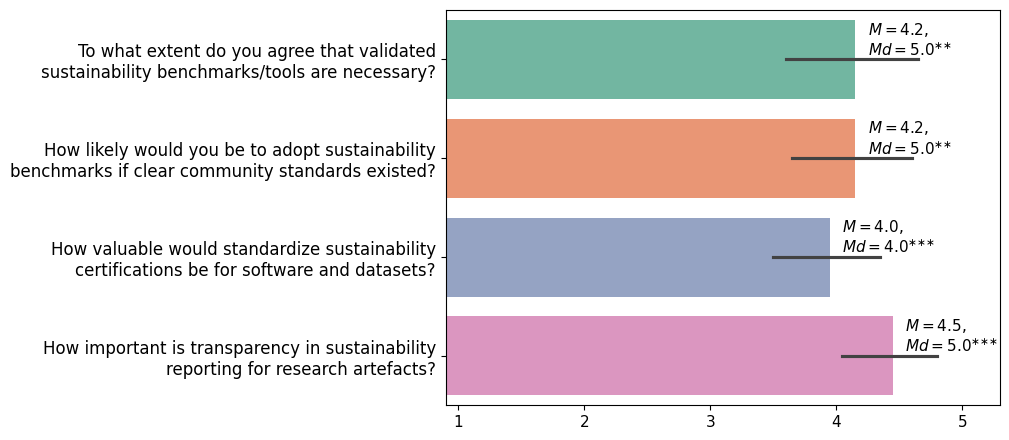

In [20]:
qs = ['To what extent do you agree that validated sustainability benchmarks/tools are necessary? 1 (Strongly disagree) – 5 (Strongly agree)',
'How likely would you be to adopt sustainability benchmarks if clear community standards existed? 1 (Not likely) – 5 (Very likely)',
'How valuable would standardize sustainability certifications (similar to FAIR badges) be for software and datasets? 1 (Not valuable) – 5 (Extremely valuable)',
'How important is transparency in sustainability reporting for research artifacts? 1 (Not important) – 5 (Extremely important)'
]
df = cleaned_data.copy()
qq = q(qs, df)
df = df[df['Selected_expert'] == 1]
df = df[qq].astype(float).dropna()
print(len(df))
vals = []
for col in df.columns:
    _, p = wilcoxon(df[col] - 3, alternative='greater')
    print(f"{col}: p={p:.3f}")
    vals.append(f"$M={np.mean(df[col]):.1f}$,\n$Md={np.median(df[col]):.1f}^{{{get_stars(p)}}}$".replace('*', r'{\ast}'))

print(vals)
draw_hbar(qs, qq, df, labels={
    qs[0]: 'To what extent do you agree that validated\nsustainability benchmarks/tools are necessary?',
    qs[1]: 'How likely would you be to adopt sustainability\nbenchmarks if clear community standards existed?', 
    qs[2]: 'How valuable would standardize sustainability\ncertifications be for software and datasets?',
    qs[3]: 'How important is transparency in sustainability\nreporting for research artefacts?', 
}, file_name='fig07a', annot=vals, figsize=(10.2, 4.5))

21


['Would lifecycle sustainability statements improve your trust in published datasets/software? [Yes]',
 'Would lifecycle sustainability statements improve your trust in published datasets/software? [No]',
 'Would lifecycle sustainability statements improve your trust in published datasets/software? [Unsure]']

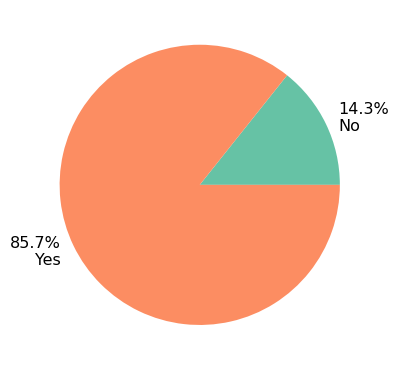

In [21]:
qs = ['Would lifecycle sustainability statements improve your trust in published datasets/software? [Yes]',
      'Would lifecycle sustainability statements improve your trust in published datasets/software? [No]',
      'Would lifecycle sustainability statements improve your trust in published datasets/software? [Unsure]']
df = cleaned_data.copy()
df = df[df['Selected_expert'] == 1]
qq = q(qs, df)
df = df[qq].dropna().replace({
    'Yes': 1,
    'No': 0,
    np.nan: 0,
    None: 0,
})
df[qq[0]] = df[qq[0]].map({
    1: 'Yes',
    0: np.nan,
})
df[qq[1]] = df[qq[1]].map({
    1: 'No',
    0: np.nan,
})
df[qq[2]] = df[qq[2]].map({
    1: 'Unsure',
    0: np.nan,
})
df['category1'] = df[qq[0]].combine_first(df[qq[1]]).combine_first(df[qq[2]])
df = df[['category1']]
print(len(df))
draw_pie(df, nrows=1, ncols=1, file_name='fig07b', width=4, height=4,
         labeldistance=1.1, )
qq


21


['Would you support mandatory disclosure of methods/tools used for energy measurement? [Yes]',
 'Would you support mandatory disclosure of methods/tools used for energy measurement? [No]',
 'Would you support mandatory disclosure of methods/tools used for energy measurement? [Unsure]']

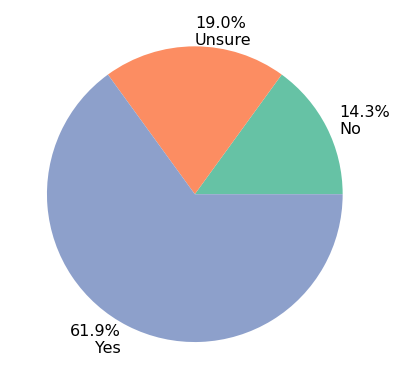

In [22]:
qs = ['Would you support mandatory disclosure of methods/tools used for energy measurement? [Yes]', 
      'Would you support mandatory disclosure of methods/tools used for energy measurement? [No]', 
      'Would you support mandatory disclosure of methods/tools used for energy measurement? [Unsure]']
df = cleaned_data.copy()
df = df[df['Selected_expert'] == 1]
qq = q(qs, df)
df = df[qq].dropna().replace({
    'Yes': 1,
    'No': 0,
    np.nan: 0,
    None: 0,
})
df[qq[0]] = df[qq[0]].map({
    1: 'Yes',
    0: np.nan,
})
df[qq[1]] = df[qq[1]].map({
    1: 'No',
    0: np.nan,
})
df[qq[2]] = df[qq[2]].map({
    1: 'Unsure',
    0: np.nan,
})
df['category2'] = df[qq[0]].combine_first(df[qq[1]]).combine_first(df[qq[2]])
df = df[['category2']]
print(len(df))
draw_pie(df, nrows=1, ncols=1, file_name='fig07c', width=4, height=4,
         labeldistance=1.1, )
qq


23
Do you consider it practical to include energy efficiency attributes in research artifact metadata? 1 (Strongly impractical) – 5 (Highly practical): p=0.124
How feasible is it to report hardware/software/network context or specifications when publishing research? 1 (Not feasible) – 5 (Very feasible): p=0.000


<Axes: >

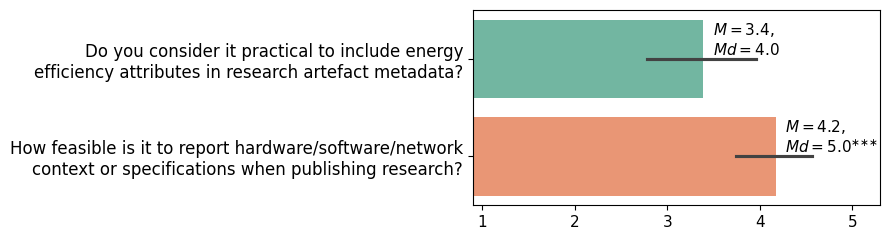

In [23]:
qs = ['Do you consider it practical to include energy efficiency attributes in research artifact metadata? 1 (Strongly impractical) – 5 (Highly practical)',
      'How feasible is it to report hardware/software/network context or specifications when publishing research? 1 (Not feasible) – 5 (Very feasible)']
df = cleaned_data.copy()
df = df[df['Selected_expert'] == 1]
qq = q(qs, df)
df = df[qq].dropna()
print(len(df))

vals = []
for col in df.columns:
    _, p = wilcoxon(df[col] - 3, alternative='greater')
    print(f"{col}: p={p:.3f}")
    # pvals.append(r"$\text{mean}=" + f"{np.mean(df[col]):.1f}, p={p:.3f}$")
    vals.append(f"$M={np.mean(df[col]):.1f}$,\n$Md={np.median(df[col]):.1f}^{{{get_stars(p)}}}$".replace('*', r'{\ast}'))

draw_hbar(qs, qq, df, labels={
    qq[0]:'Do you consider it practical to include energy\nefficiency attributes in research artefact metadata?',
    qq[1]:'How feasible is it to report hardware/software/network\ncontext or specifications when publishing research?', 
}, file_name='fig08a', figsize=(9, 2.5), annot=vals)

27
                          0
0              CPU/GPU type
1              CPU/GPU type
2              CPU/GPU type
3              CPU/GPU type
5              CPU/GPU type
..                      ...
13  System logs/Energy logs
7              None of them
8              None of them
13                    Other
25                    Other

[63 rows x 1 columns]


['Which hardware/software details do you usually report in any of your research (if any)? [CPU / GPU type]',
 'Which hardware/software details do you usually report in any of your research (if any)? [Memory]',
 'Which hardware/software details do you usually report in any of your research (if any)? [Software framework]',
 'Which hardware/software details do you usually report in any of your research (if any)? [Operating System / Environment]',
 'Which hardware/software details do you usually report in any of your research (if any)? [Cloud provider / Region]',
 'Which hardware/software details do you usually report in any of your research (if any)? [System logs / Energy logs]',
 'Which hardware/software details do you usually report in any of your research (if any)? [None of them]',
 'Which hardware/software details do you usually report in any of your research (if any)? [Other]']

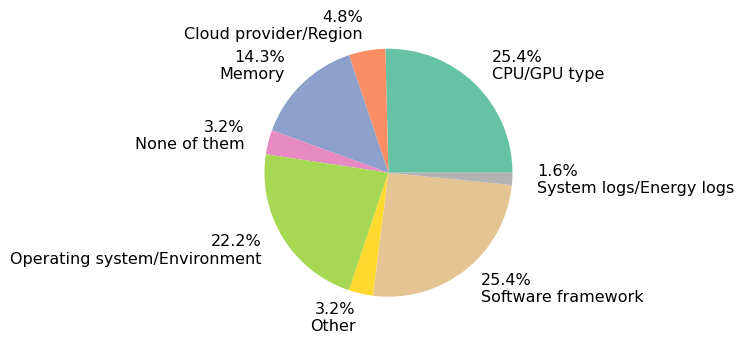

In [24]:
qs = ['Which hardware/software details do you usually report in any of your research (if any)? [CPU / GPU type]',
 'Which hardware/software details do you usually report in any of your research (if any)? [Memory]',
 'Which hardware/software details do you usually report in any of your research (if any)? [Software framework]',
 'Which hardware/software details do you usually report in any of your research (if any)? [Operating System / Environment]',
 'Which hardware/software details do you usually report in any of your research (if any)? [Cloud provider / Region]',
 'Which hardware/software details do you usually report in any of your research (if any)? [System logs / Energy logs]',
 'Which hardware/software details do you usually report in any of your research (if any)? [None of them]',
 'Which hardware/software details do you usually report in any of your research (if any)? [Other]']
df = cleaned_data.copy()
df = df[df['Selected_expert'] == 1]
qq = q(qs, df)
df = df[qq].replace({
    'Yes': 1,
    'No': 0,
    np.nan: 0,
    None: 0,
})
print(len(df))
df[qq[0]] = df[qq[0]].map({
    1: 'CPU/GPU type',
    0: np.nan,
})
df[qq[1]] = df[qq[1]].map({
    1: 'Memory',
    0: np.nan,
})
df[qq[2]] = df[qq[2]].map({
    1: 'Software framework',
    0: np.nan,
})
df[qq[3]] = df[qq[3]].map({
    1: 'Operating system/Environment',
    0: np.nan,
})
df[qq[4]] = df[qq[4]].map({
    1: 'Cloud provider/Region',
    0: np.nan,
})
df[qq[5]] = df[qq[5]].map({
    1: 'System logs/Energy logs',
    0: np.nan,
})
df[qq[6]] = df[qq[6]].map({
    1: 'None of them',
    0: np.nan,
})
df[qq[7]] = df[qq[7]].apply(lambda x: 'Other' if x != 0 else np.nan)
df = pd.DataFrame(pd.concat([df[i] for i in df.columns], axis=0).dropna())
print(df)
draw_pie(df, nrows=1, ncols=1, file_name='fig08b',
         labeldistance=1.2, width=4, height=4.5)
qq